<a href="https://colab.research.google.com/github/Abhijith526/machine-learning/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!unzip -q "/content/archive (1).zip" -d /content/fer2013

replace /content/fer2013/test/angry/PrivateTest_10131363.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [ ]:
import os

print(os.listdir("/content/fer2013"))

['train', 'test']


In [ ]:
import os

for root, dirs, files in os.walk("/content/fer2013"):
    level = root.replace("/content/fer2013", "").count(os.sep)
    indent = "  " * level
    print(indent + os.path.basename(root) + "/")

    if level < 2:
        for file in files[:5]:
            print(indent + "  " + file)

fer2013/
  train/
    angry/
    fear/
    surprise/
    happy/
    sad/
    disgust/
    neutral/
  test/
    angry/
    fear/
    surprise/
    happy/
    sad/
    disgust/
    neutral/


In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

In [ ]:
classes = {
    "happy": 0,
    "sad": 1
}

print(classes)

{'happy': 0, 'sad': 1}


In [ ]:
dataset_path = "/content/fer2013/train"

X = []
y = []

for emotion, label in classes.items():

    folder = os.path.join(dataset_path, emotion)

    for filename in os.listdir(folder):

        image_path = os.path.join(folder, filename)

        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

        if image is None:
            continue

        # Resize to 24 x 24
        image = cv2.resize(image, (24, 24))

        # Convert image to feature vector
        image = image.flatten()

        X.append(image)
        y.append(label)

X = np.array(X)
y = np.array(y)

print("Feature matrix shape:", X.shape)
print("Label shape:", y.shape)

Feature matrix shape: (12045, 576)
Label shape: (12045,)


In [ ]:
X = X.astype("float32") / 255.0

print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


In [ ]:
print("Happy images:", np.sum(y == 0))
print("Sad images:", np.sum(y == 1))

Happy images: 7215
Sad images: 4830


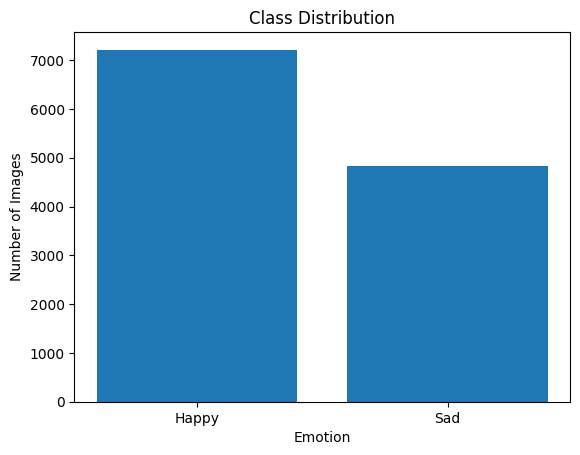

In [ ]:
plt.bar(["Happy", "Sad"], [
    np.sum(y == 0),
    np.sum(y == 1)
])

plt.xlabel("Emotion")
plt.ylabel("Number of Images")
plt.title("Class Distribution")
plt.show()

In [ ]:
#A3
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

In [ ]:
print("Training feature shape:", X_train.shape)
print("Testing feature shape:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training feature shape: (8431, 576)
Testing feature shape: (3614, 576)
Training labels: (8431,)
Testing labels: (3614,)


In [ ]:
#A4
neigh = KNeighborsClassifier(n_neighbors=3)

neigh.fit(X_train, y_train)

print("kNN model trained successfully.")

kNN model trained successfully.


In [ ]:
#A5
accuracy = neigh.score(X_test, y_test)

print("kNN Accuracy:", accuracy)
print("kNN Accuracy (%):", accuracy * 100)

kNN Accuracy: 0.6488655229662423
kNN Accuracy (%): 64.88655229662423


In [ ]:
#A6
predictions = neigh.predict(X_test)

print("First 20 predictions:")
print(predictions[:20])

print("\nFirst 20 actual labels:")
print(y_test[:20])

First 20 predictions:
[0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 1 0 1 0 1]

First 20 actual labels:
[1 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 1 0 0 0]


In [ ]:
label_names = {
    0: "Happy",
    1: "Sad"
}

for actual, predicted in zip(y_test[:20], predictions[:20]):
    print(
        "Actual:", label_names[actual],
        "| Predicted:", label_names[predicted]
    )

Actual: Sad | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Sad | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Sad | Predicted: Happy
Actual: Happy | Predicted: Sad
Actual: Happy | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Happy | Predicted: Happy
Actual: Sad | Predicted: Sad
Actual: Happy | Predicted: Happy
Actual: Sad | Predicted: Sad
Actual: Sad | Predicted: Happy
Actual: Happy | Predicted: Sad
Actual: Happy | Predicted: Happy
Actual: Happy | Predicted: Sad


In [ ]:
#A7
class MyKNN:

    def __init__(self, k=3):
        self.k = k

    def Fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def Predict(self, X):

        predictions = []

        for sample in X:

            # Calculate Euclidean distance
            distances = np.sqrt(
                np.sum(
                    (self.X_train - sample) ** 2,
                    axis=1
                )
            )

            # Get indices of k nearest neighbors
            nearest_indices = np.argsort(distances)[:self.k]

            # Get their class labels
            nearest_labels = self.y_train[nearest_indices]

            # Majority voting
            prediction = Counter(
                nearest_labels
            ).most_common(1)[0][0]

            predictions.append(prediction)

        return np.array(predictions)

    def Score(self, X, y):

        predictions = self.Predict(X)

        accuracy = np.mean(predictions == y)

        return accuracy

In [ ]:
my_knn = MyKNN(k=3)

my_knn.Fit(X_train, y_train)

my_predictions = my_knn.Predict(X_test)

my_accuracy = my_knn.Score(X_test, y_test)

print("My kNN Accuracy:", my_accuracy)
print("My kNN Accuracy (%):", my_accuracy * 100)

My kNN Accuracy: 0.6488655229662423
My kNN Accuracy (%): 64.88655229662423


In [ ]:
#A8

In [20]:
k_values = [1, 3, 5, 7, 9, 11]

sklearn_accuracies = []
custom_accuracies = []

for k in k_values:

    # -------------------------
    # Scikit-Learn kNN
    # -------------------------
    sklearn_knn = KNeighborsClassifier(
        n_neighbors=k
    )

    sklearn_knn.fit(X_train, y_train)

    sklearn_accuracy = sklearn_knn.score(
        X_test,
        y_test
    )

    sklearn_accuracies.append(
        sklearn_accuracy
    )

    # -------------------------
    # Custom kNN
    # -------------------------
    custom_knn = MyKNN(k=k)

    custom_knn.Fit(
        X_train,
        y_train
    )

    custom_accuracy = custom_knn.Score(
        X_test,
        y_test
    )

    custom_accuracies.append(
        custom_accuracy
    )

    print(
        "k =", k,
        "| Scikit-Learn =",
        round(sklearn_accuracy * 100, 2),
        "%",
        "| Custom =",
        round(custom_accuracy * 100, 2),
        "%"
    )

k = 1 | Scikit-Learn = 64.36 % | Custom = 64.36 %
k = 3 | Scikit-Learn = 64.89 % | Custom = 64.89 %
k = 5 | Scikit-Learn = 65.88 % | Custom = 65.88 %
k = 7 | Scikit-Learn = 65.38 % | Custom = 65.38 %
k = 9 | Scikit-Learn = 65.5 % | Custom = 65.5 %
k = 11 | Scikit-Learn = 65.41 % | Custom = 65.41 %
